## Rayleigh Quotient Optimization of the PCA Objective

Here, we perform eigendecomposition of the covariance matrix in two different ways: (1) via the Eigendecomposition of the covariance matrix directly, and (2) via Rayleigh Quotient Optimization of the PCA objective:

$$\mathbb{E}_{i \sim \nu} [e_i^\top (\theta) C e_i(\theta)] = \mathbb{E}_{i \sim \nu, x \sim p} \left[e_i^\top(\theta) \, (x - m)^2\right]$$

where $\mu$ is the average and $\nu$ is a distribution over the indices of the eigenvectors. We will then show that if $\nu$ is non-zero, then it will recover the eigenvectors of the covariance matrix up to permutation, and the permutation is determined by the weights in $\nu$. In particular, the largest weight in $\nu$ will correspond to the top eigenvector of the covariance matrix, the second largest weight will correspond to the second eigenvector, and so on. If there are ties in the weights, then the corresponding eigenvectors can be in any order and degenerate eigenspaces are possible.



The following generates a synthetic dataset with an eigenvalue spectrum that decays. Then, it parmaeterizes a set of orthogonal vectors-reparameterized with QR decomposition to ensure orthogonality-and optimizes the Rayleigh quotient objective using SGD. Finally, it compares the results with the eigendecomposition of the covariance matrix directly.

100%|██████████| 150000/150000 [01:06<00:00, 2262.40it/s]


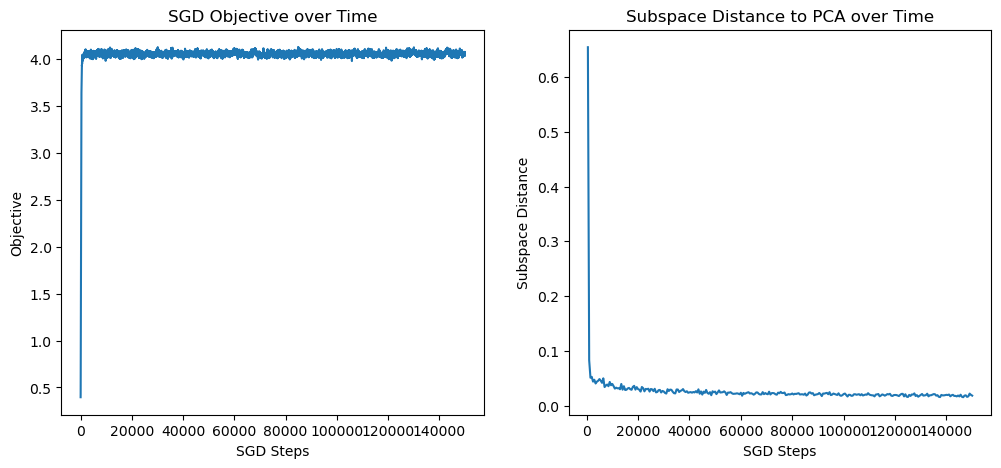

In [15]:
import numpy as np
import torch
from tqdm import tqdm

torch.manual_seed(0)
np.random.seed(0)

# ----------------------------
# 1) Make synthetic data X (n x d) with a clear top-K subspace
# ----------------------------
n, d, K = 2000, 50, 5

# True latent subspace
U_true, _ = np.linalg.qr(np.random.randn(d, K))  # d x K orthonormal
# Latent scores + noise
Lambda = np.linspace(5.0, 1.0, K)  # decreasing eigenvalues
Z = np.random.randn(n, K) * np.sqrt(Lambda)  # n x K
noise = 0.2 * np.random.randn(n, d)
X_np = Z @ U_true.T + noise
X = torch.tensor(X_np, dtype=torch.float32)

# Centering (PCA convention)
X = X - X.mean(dim=0, keepdim=True)

# ----------------------------
# 2) Closed-form PCA subspace via SVD of X (not XX^T)
#    X = U S V^T, top-K PCs are columns of V[:, :K]
# ----------------------------
# (Using torch.linalg.svd; you can also use np.linalg.svd)
U, S, Vt = torch.linalg.svd(X, full_matrices=False)
Q_pca = Vt[:K].T.contiguous()  # d x K, orthonormal PCs

# ----------------------------
# 3) SGD on weighted random (i,j) objective with orthonormal Q via QR
#    Loss for sample (i,j): ||x_j - x_j q_i q_i^T||^2
#    = ||x_j||^2 - (x_j^T q_i)^2  (constant term ignored)
# ----------------------------
# Column selection probabilities (non-uniform, decreasing)
# NOTE: play with this to find the effect of sampling distribution
# p = torch.tensor([0.45, 0.25, 0.15, 0.10, 0.05], dtype=torch.float32)
p = torch.tensor([0.1, 0.3, 0.2, 0.5, 0.01], dtype=torch.float32)
p = p / p.sum()  # just in case

# Unconstrained parameter A, QR(A) -> Q orthonormal
A = torch.randn(d, K, requires_grad=True)
opt = torch.optim.Adam([A], lr=1e-2)

batch_size = 256
B, Bprime = batch_size, 50  # datapoints and columns per SGD step
steps = 150000
alpha = 0.01
obj_history = []
subspace_distances = []

before_Q, _ = torch.linalg.qr(A.detach(), mode="reduced")

for t in tqdm(range(steps)):
    Q, _ = torch.linalg.qr(A, mode="reduced")  # (d, K)

    # sample datapoints j (size B) and columns i (size B')
    j = torch.randint(0, n, (B,), device=X.device)
    i = torch.multinomial(p.to(X.device), num_samples=Bprime, replacement=True)

    x = X[j]           # (B, d)
    q = Q[:, i].T      # (B', d)

    # all pair dot-products: (B, B')
    dots = x @ q.T
    rayleigh_quotient = (dots.pow(2)).mean()

    opt.zero_grad()
    (-rayleigh_quotient).backward()
    opt.step()

    obj_history.append(rayleigh_quotient.item() * alpha + (1 - alpha) * obj_history[-1] if obj_history else rayleigh_quotient.item())
    if (t + 1) % 500 == 0:
        with torch.no_grad():
            # Learned orthonormal Q
            Q_sgd, _ = torch.linalg.qr(A.detach(), mode="reduced")

            # ----------------------------
            # 4) Compare *subspaces* via principal angles / projection distance
            # ----------------------------
            # Projection matrices onto subspaces
            P_pca = Q_pca @ Q_pca.T
            P_sgd = Q_sgd @ Q_sgd.T

            # Subspace distance: ||P1 - P2||_F / sqrt(2)  (0 means identical subspace)
            dist = torch.linalg.norm(P_pca - P_sgd, ord="fro") / np.sqrt(2.0)
            subspace_distances.append(dist.item())

from matplotlib import pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(obj_history)
plt.title("SGD Objective over Time")
plt.xlabel("SGD Steps")
plt.ylabel("Objective")
plt.subplot(1, 2, 2)
plt.plot(np.arange(500, steps + 1, 500), subspace_distances)
plt.title("Subspace Distance to PCA over Time")
plt.xlabel("SGD Steps")
plt.ylabel("Subspace Distance")
plt.show()


The following piece of code visualizes the captured variances along each direction. Up to permutation, the variances should match, also the ordering should be determined by the weights in the sampling distribution.

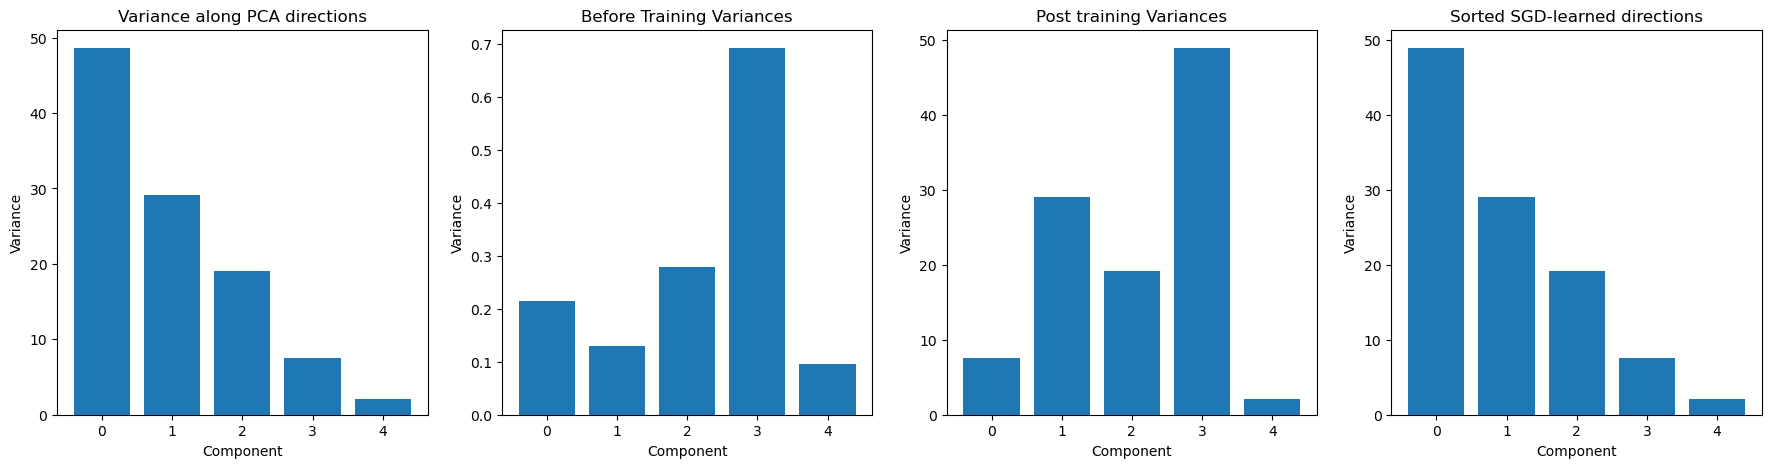

In [16]:
# plot the variance of the data along the learned directions vs PCA directions
var_pca = (X_np @ Q_pca.numpy())**2
var_sgd = (X_np @ Q_sgd.numpy())**2
var_before = (X_np @ before_Q.numpy())**2
var_pca = var_pca.var(axis=0)
var_sgd = var_sgd.var(axis=0)
var_before = var_before.var(axis=0)
# sort according to the argsort of the probabilities
arg_sorted = torch.argsort(p, descending=True).numpy()
sorted_var_sgd = var_sgd[arg_sorted]
plt.figure(figsize=(22, 5))
plt.subplot(1, 4, 1)
plt.bar(np.arange(K), var_pca)
plt.title("Variance along PCA directions")
plt.xlabel("Component")
plt.ylabel("Variance")
plt.subplot(1, 4, 2)
plt.bar(np.arange(K), var_before)
plt.title("Before Training Variances")
plt.xlabel("Component")
plt.ylabel("Variance")
plt.subplot(1, 4, 3)
plt.bar(np.arange(K), var_sgd)
plt.title("Post training Variances")
plt.xlabel("Component")
plt.ylabel("Variance")
plt.subplot(1, 4, 4)
plt.bar(np.arange(K), sorted_var_sgd)
plt.title("Sorted SGD-learned directions")
plt.xlabel("Component")
plt.ylabel("Variance")
plt.show()